# MTA Daily Ridership Analysis - Comprehensive Data Science Project

**Dataset:** MTA Daily Ridership (March 2020 - October 2024)

---

## Project Overview

This notebook analyzes MTA ridership recovery from the COVID-19 pandemic, examining:
- 7 transit services (Subways, Buses, LIRR, Metro-North, Access-A-Ride, Bridges & Tunnels, SIR)
- 1,706 days of data (March 2020 - October 2024)
- 4 key business questions about recovery patterns



In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("[OK] Libraries imported successfully")

[OK] Libraries imported successfully


In [4]:
# Load the MTA ridership data
df = pd.read_csv('MTA_Daily_Ridership.csv')

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total days: {len(df):,}")

# Show first few rows
df.head()

Dataset shape: (1706, 15)
Date range: 2020-03-01 00:00:00 to 2024-10-31 00:00:00
Total days: 1,706


,Date,Subways: Total Estimated Ridership,Subways: % of Comparable Pre-Pandemic Day,Buses: Total Estimated Ridership,Buses: % of Comparable Pre-Pandemic Day,LIRR: Total Estimated Ridership,LIRR: % of Comparable Pre-Pandemic Day,Metro-North: Total Estimated Ridership,Metro-North: % of Comparable Pre-Pandemic Day,Access-A-Ride: Total Scheduled Trips,Access-A-Ride: % of Comparable Pre-Pandemic Day,Bridges and Tunnels: Total Traffic,Bridges and Tunnels: % of Comparable Pre-Pandemic Day,Staten Island Railway: Total Estimated Ridership,Staten Island Railway: % of Comparable Pre-Pandemic Day
0,2020-03-01,2212965,97,984908,99,86790,100,55825,59,19922,113,786960,98,1636,52
1,2020-03-02,5329915,96,2209066,99,321569,103,180701,66,30338,102,874619,95,17140,107
2,2020-03-03,5481103,98,2228608,99,319727,102,190648,69,32767,110,882175,96,17453,109
3,2020-03-04,5498809,99,2177165,97,311662,99,192689,70,34297,115,905558,98,17136,107
4,2020-03-05,5496453,99,2244515,100,307597,98,194386,70,33209,112,929298,101,17203,108


In [5]:
# Rename columns for easier manipulation
col_mapping = {}
for col in df.columns:
    if 'Total Estimated Ridership' in col or 'Total Scheduled Trips' in col or 'Total Traffic' in col:
        service = col.split(':')[0]
        col_mapping[col] = f'{service}_Volume'
    elif '% of Comparable Pre-Pandemic Day' in col:
        service = col.split(':')[0]
        col_mapping[col] = f'{service}_Pct'

df.rename(columns=col_mapping, inplace=True)

print("[OK] Columns renamed")
print(f"\nColumn names: {df.columns.tolist()[:10]}...")

[OK] Columns renamed

Column names: ['Date', 'Subways_Volume', 'Subways_Pct', 'Buses_Volume', 'Buses_Pct', 'LIRR_Volume', 'LIRR_Pct', 'Metro-North_Volume', 'Metro-North_Pct', 'Access-A-Ride_Volume']...


In [6]:
# Feature engineering - Add time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['DaysSinceMarch2020'] = (df['Date'] - pd.to_datetime('2020-03-01')).dt.days

print("[OK] Feature engineering complete")
print(f"\nNew features: Year, Month, DayOfWeek, IsWeekend, Quarter, DaysSinceMarch2020")

[OK] Feature engineering complete

New features: Year, Month, DayOfWeek, IsWeekend, Quarter, DaysSinceMarch2020


##  Exploratory Data Analysis

In [7]:
# Check for missing values
print("Missing values by column:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
df.describe()

Missing values by column:
Date                            0
Subways_Volume                  0
Subways_Pct                     0
Buses_Volume                    0
Buses_Pct                       0
LIRR_Volume                     0
LIRR_Pct                        0
Metro-North_Volume              0
Metro-North_Pct                 0
Access-A-Ride_Volume            0
Access-A-Ride_Pct               0
Bridges and Tunnels_Volume      0
Bridges and Tunnels_Pct         0
Staten Island Railway_Volume    0
Staten Island Railway_Pct       0
Year                            0
Month                           0
DayOfWeek                       0
IsWeekend                       0
WeekOfYear                      0
Quarter                         0
DaysSinceMarch2020              0
dtype: int64

Basic statistics:


,Date,Subways_Volume,Subways_Pct,Buses_Volume,Buses_Pct,LIRR_Volume,LIRR_Pct,Metro-North_Volume,Metro-North_Pct,Access-A-Ride_Volume,...,Bridges and Tunnels_Pct,Staten Island Railway_Volume,Staten Island Railway_Pct,Year,Month,DayOfWeek,IsWeekend,WeekOfYear,Quarter,DaysSinceMarch2020
count,1706,1.706000e+03,1706.000000,1.706000e+03,1706.000000,1706.000000,1706.000000,1706.000000,1706.000000,1706.000000,...,1706.000000,1706.000000,1706.000000,1706.000000,1706.00000,1706.000000,1706.000000,1706.0,1706.000000,1706.000000
mean,2022-07-01 12:00:00,2.509055e+06,55.461313,1.006868e+06,54.692849,135960.116061,59.128370,114888.273154,51.083236,21941.532825,...,93.375147,4429.355217,37.811254,2021.998828,6.51993,2.998242,0.285463,26.639508,2.507620,852.500000
min,2020-03-01 00:00:00,1.983990e+05,7.000000,5.498000e+03,1.000000,1903.000000,2.000000,3281.000000,3.000000,2506.000000,...,18.000000,0.000000,0.000000,2020.000000,1.00000,0.000000,0.000000,1.0,1.000000,0.000000
25%,2021-05-01 06:00:00,1.715396e+06,40.000000,7.152495e+05,53.000000,78689.750000,37.000000,51271.250000,29.000000,15869.500000,...,90.000000,2077.250000,24.000000,2021.000000,4.00000,1.000000,0.000000,14.0,2.000000,426.250000
50%,2022-07-01 12:00:00,2.459607e+06,61.000000,1.140776e+06,60.000000,124274.000000,60.000000,108237.000000,56.000000,22301.500000,...,97.000000,4522.500000,40.000000,2022.000000,7.00000,3.000000,0.000000,27.0,3.000000,852.500000
75%,2023-08-31 18:00:00,3.440053e+06,69.000000,1.347620e+06,65.000000,197928.000000,76.000000,176789.750000,71.000000,27506.750000,...,102.000000,6812.750000,47.000000,2023.000000,9.00000,5.000000,1.000000,39.0,3.000000,1278.750000
max,2024-10-31 00:00:00,5.498809e+06,143.000000,2.244515e+06,126.000000,321569.000000,237.000000,249585.000000,193.000000,40468.000000,...,120.000000,17453.000000,182.000000,2024.000000,12.00000,6.000000,1.000000,53.0,4.000000,1705.000000
std,NaN,1.062184e+06,19.819596,4.403799e+05,19.293307,71298.778711,29.297993,66500.207696,26.137311,7990.634806,...,14.641962,2681.655564,19.273205,1.364398,3.30873,2.001025,0.451767,14.475894,1.085333,492.624096


In [8]:
# Current recovery status (latest data point)
services = ['Subways', 'Buses', 'LIRR', 'Metro-North', 'Access-A-Ride', 
            'Bridges and Tunnels', 'Staten Island Railway']

latest = df.iloc[-1]

print(f"Current Recovery Status (as of {latest['Date'].strftime('%Y-%m-%d')}):")
print("=" * 60)
for service in services:
    pct_col = f'{service}_Pct'
    if pct_col in df.columns:
        current_pct = latest[pct_col]
        status = "[RECOVERED] RECOVERED" if current_pct >= 100 else "[RECOVERING] RECOVERING"
        print(f"{service:25s}: {current_pct:6.1f}% {status}")

Current Recovery Status (as of 2024-10-31):
Subways                  :   70.0% [RECOVERING] RECOVERING
Buses                    :   58.0% [RECOVERING] RECOVERING
LIRR                     :   82.0% [RECOVERING] RECOVERING
Metro-North              :   76.0% [RECOVERING] RECOVERING
Access-A-Ride            :  126.0% [RECOVERED] RECOVERED
Bridges and Tunnels      :  103.0% [RECOVERED] RECOVERED
Staten Island Railway    :   42.0% [RECOVERING] RECOVERING


##  Share of Traffic by Service


In [9]:
# Pre-pandemic period (March 1-7, 2020)
pre_pandemic = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-03-07')]

# Recent period (last 30 days)
recent = df.tail(30)

# Calculate totals
pre_totals = {}
recent_totals = {}

for service in services:
    vol_col = f'{service}_Volume'
    if vol_col in df.columns:
        pre_totals[service] = pre_pandemic[vol_col].sum()
        recent_totals[service] = recent[vol_col].sum()

# Calculate market shares
pre_total = sum(pre_totals.values())
recent_total = sum(recent_totals.values())

print("PRE-PANDEMIC TRAFFIC SHARE (March 1-7, 2020):")
print("=" * 60)
pre_shares = {}
for service, total in sorted(pre_totals.items(), key=lambda x: x[1], reverse=True):
    share = (total / pre_total) * 100
    pre_shares[service] = share
    print(f"{service:25s}: {share:6.2f}% ({total:12,.0f} trips)")

print("\nCURRENT TRAFFIC SHARE (Last 30 Days):")
print("=" * 60)
recent_shares = {}
for service, total in sorted(recent_totals.items(), key=lambda x: x[1], reverse=True):
    share = (total / recent_total) * 100
    recent_shares[service] = share
    change = share - pre_shares.get(service, 0)
    arrow = "(+)" if change > 0 else "(-)" if change < 0 else "(=)"
    print(f"{service:25s}: {share:6.2f}% ({total:12,.0f} trips) {arrow} {abs(change):+.2f}pp")

PRE-PANDEMIC TRAFFIC SHARE (March 1-7, 2020):
Subways                  :  58.80% (  32,023,329 trips)
Buses                    :  24.16% (  13,160,090 trips)
Bridges and Tunnels      :  11.30% (   6,151,925 trips)
LIRR                     :   3.20% (   1,742,574 trips)
Metro-North              :   2.01% (   1,095,143 trips)
Access-A-Ride            :   0.37% (     199,620 trips)
Staten Island Railway    :   0.16% (      88,298 trips)

CURRENT TRAFFIC SHARE (Last 30 Days):
Subways                  :  57.34% ( 109,237,723 trips) (-) +1.46pp
Buses                    :  20.25% (  38,586,117 trips) (-) +3.91pp
Bridges and Tunnels      :  14.95% (  28,481,482 trips) (+) +3.65pp
LIRR                     :   3.60% (   6,854,526 trips) (+) +0.40pp
Metro-North              :   3.22% (   6,134,813 trips) (+) +1.21pp
Access-A-Ride            :   0.53% (   1,008,531 trips) (+) +0.16pp
Staten Island Railway    :   0.10% (     199,645 trips) (-) +0.06pp


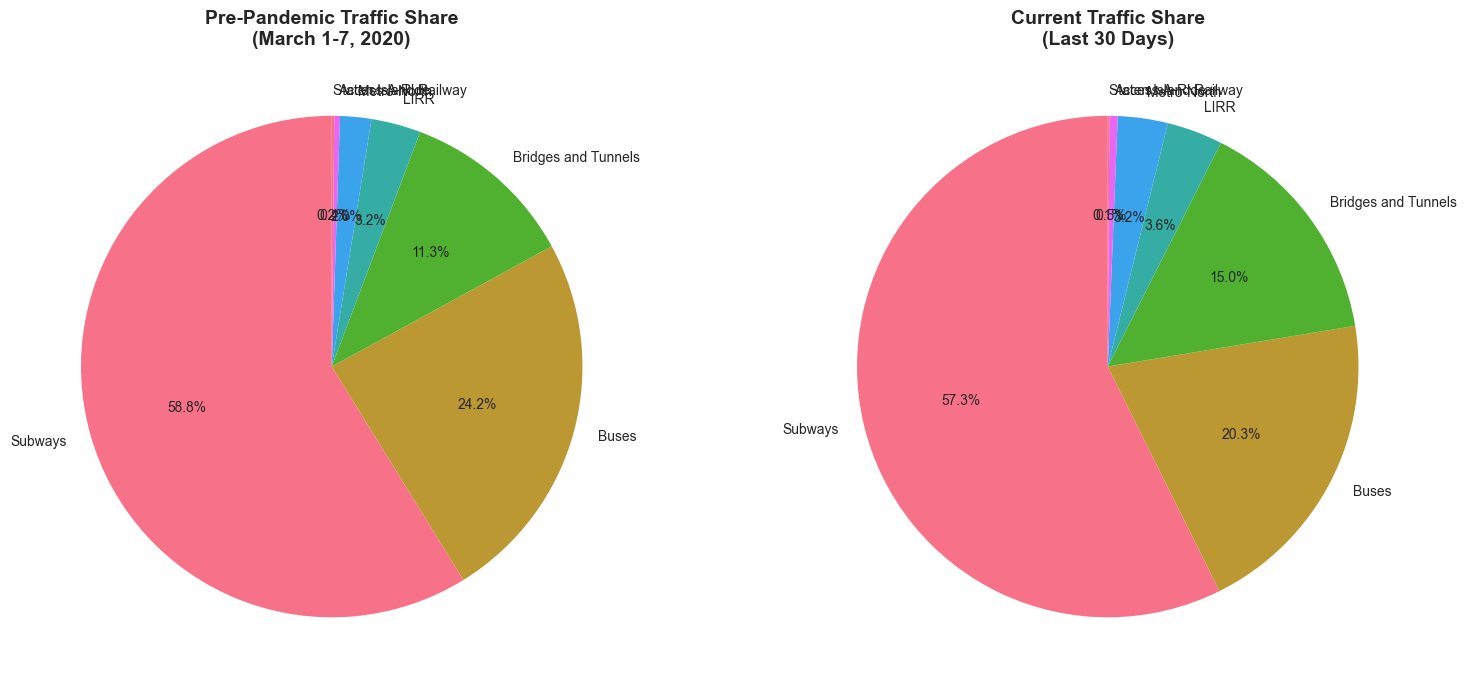


[!] KEY INSIGHT:
Bridges & Tunnels gained the most market share (+3.65pp)
Buses lost the most market share (-3.91pp)


In [10]:
# Visualization: Pre vs Post Traffic Share
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Pre-pandemic pie chart
ax1.pie(list(pre_shares.values()), labels=list(pre_shares.keys()), 
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Pre-Pandemic Traffic Share\n(March 1-7, 2020)', 
              fontsize=14, fontweight='bold')

# Recent pie chart
ax2.pie(list(recent_shares.values()), labels=list(recent_shares.keys()), 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Current Traffic Share\n(Last 30 Days)', 
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[!] KEY INSIGHT:")
print(f"Bridges & Tunnels gained the most market share (+{max((recent_shares[s] - pre_shares[s]) for s in services):.2f}pp)")
print(f"Buses lost the most market share ({min((recent_shares[s] - pre_shares[s]) for s in services):.2f}pp)")

## Biggest Drop-off and Recovery

In [11]:
# Find minimum points for each service
dropoffs = {}

for service in services:
    pct_col = f'{service}_Pct'
    if pct_col in df.columns:
        min_pct = df[pct_col].min()
        min_idx = df[pct_col].idxmin()
        min_date = df.loc[min_idx, 'Date']
        current_pct = df[pct_col].iloc[-1]
        
        dropoffs[service] = {
            'min_pct': min_pct,
            'min_date': min_date,
            'drop_magnitude': 100 - min_pct,
            'current_pct': current_pct,
            'recovery_rate': ((current_pct - min_pct) / (100 - min_pct)) * 100 if min_pct < 100 else 100
        }

# Sort by drop magnitude
sorted_drops = sorted(dropoffs.items(), key=lambda x: x[1]['drop_magnitude'], reverse=True)

print("SERVICES RANKED BY SEVERITY OF DROP:")
print("=" * 70)
for i, (service, data) in enumerate(sorted_drops, 1):
    print(f"\n{i}. {service}")
    print(f"   Lowest Point: {data['min_pct']:.1f}% on {data['min_date'].strftime('%Y-%m-%d')}")
    print(f"   Drop: {data['drop_magnitude']:.1f} percentage points")
    print(f"   Current: {data['current_pct']:.1f}%")
    print(f"   Recovery: {data['recovery_rate']:.1f}% of the way back")
    
    if data['current_pct'] >= 100:
        print(f"   Status: [RECOVERED] FULLY RECOVERED")
    elif data['current_pct'] >= 90:
        print(f"   Status: [!] Near recovery")
    else:
        print(f"   Status: [X] Still recovering")

SERVICES RANKED BY SEVERITY OF DROP:

1. Staten Island Railway
   Lowest Point: 0.0% on 2020-05-30
   Drop: 100.0 percentage points
   Current: 42.0%
   Recovery: 42.0% of the way back
   Status: [X] Still recovering

2. Buses
   Lowest Point: 1.0% on 2020-03-28
   Drop: 99.0 percentage points
   Current: 58.0%
   Recovery: 57.6% of the way back
   Status: [X] Still recovering

3. LIRR
   Lowest Point: 2.0% on 2020-04-11
   Drop: 98.0 percentage points
   Current: 82.0%
   Recovery: 81.6% of the way back
   Status: [X] Still recovering

4. Metro-North
   Lowest Point: 3.0% on 2020-04-01
   Drop: 97.0 percentage points
   Current: 76.0%
   Recovery: 75.3% of the way back
   Status: [X] Still recovering

5. Subways
   Lowest Point: 7.0% on 2020-04-09
   Drop: 93.0 percentage points
   Current: 70.0%
   Recovery: 67.7% of the way back
   Status: [X] Still recovering

6. Access-A-Ride
   Lowest Point: 13.0% on 2020-04-26
   Drop: 87.0 percentage points
   Current: 126.0%
   Recovery: 129.9

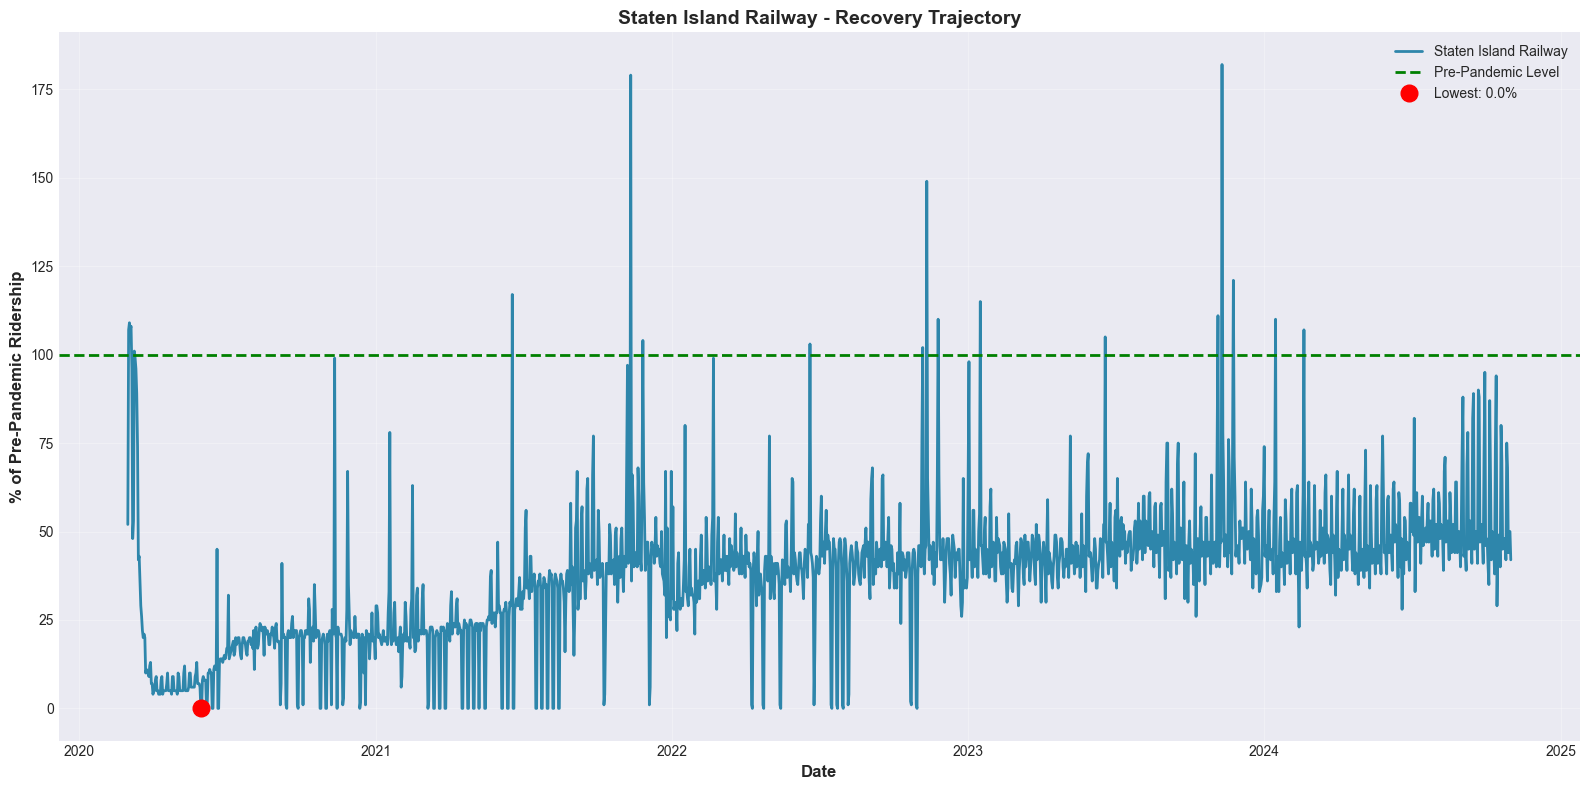

In [12]:
# Visualization: Recovery trajectory for worst-hit service
worst_service = sorted_drops[0][0]
pct_col = f'{worst_service}_Pct'

plt.figure(figsize=(16, 8))
plt.plot(df['Date'], df[pct_col], linewidth=2, label=worst_service, color='#2E86AB')
plt.axhline(y=100, color='green', linestyle='--', label='Pre-Pandemic Level', linewidth=2)

# Mark minimum point
min_idx = df[pct_col].idxmin()
min_date = df.loc[min_idx, 'Date']
min_pct = df.loc[min_idx, pct_col]
plt.plot(min_date, min_pct, 'ro', markersize=12, label=f'Lowest: {min_pct:.1f}%')

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('% of Pre-Pandemic Ridership', fontsize=12, fontweight='bold')
plt.title(f'{worst_service} - Recovery Trajectory', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fastest Recovery Analysis

In [13]:
# Recovery velocity and milestone analysis
recovery_metrics = {}

for service in services:
    pct_col = f'{service}_Pct'
    if pct_col not in df.columns:
        continue
    
    # Find minimum point
    min_idx = df[pct_col].idxmin()
    min_date = df.loc[min_idx, 'Date']
    min_pct = df.loc[min_idx, pct_col]
    
    # Data after minimum
    recovery_df = df[df['Date'] > min_date].copy()
    
    if len(recovery_df) == 0:
        continue
    
    # Find milestone dates
    milestones = {}
    for milestone_pct in [50, 75, 90, 100]:
        milestone_df = recovery_df[recovery_df[pct_col] >= milestone_pct]
        if len(milestone_df) > 0:
            milestone_date = milestone_df['Date'].iloc[0]
            days_to_milestone = (milestone_date - min_date).days
            milestones[f'{milestone_pct}%'] = {
                'date': milestone_date,
                'days': days_to_milestone
            }
    
    # Recovery velocity
    current_pct = df[pct_col].iloc[-1]
    days_since_min = (df['Date'].iloc[-1] - min_date).days
    velocity = (current_pct - min_pct) / days_since_min if days_since_min > 0 else 0
    
    recovery_metrics[service] = {
        'min_date': min_date,
        'min_pct': min_pct,
        'current_pct': current_pct,
        'milestones': milestones,
        'velocity': velocity
    }

# Display fastest to each milestone
print("🏆 FASTEST TO RECOVERY MILESTONES:")
print("=" * 70)

for milestone in ['50%', '75%', '90%', '100%']:
    print(f"\n{milestone} Recovery:")
    milestone_rankings = []
    
    for service, metrics in recovery_metrics.items():
        if milestone in metrics['milestones']:
            milestone_rankings.append((
                service,
                metrics['milestones'][milestone]['days'],
                metrics['milestones'][milestone]['date']
            ))
    
    milestone_rankings.sort(key=lambda x: x[1])
    
    for i, (service, days, date) in enumerate(milestone_rankings[:3], 1):
        medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉"
        print(f"   {medal} {service:25s}: {days:4d} days ({date.strftime('%Y-%m-%d')})")

🏆 FASTEST TO RECOVERY MILESTONES:

50% Recovery:
   🥇 Bridges and Tunnels      :    2 days (2021-02-03)
   🥈 Access-A-Ride            :   52 days (2020-06-17)
   🥉 LIRR                     :   69 days (2020-06-19)

75% Recovery:
   🥇 Bridges and Tunnels      :    3 days (2021-02-04)
   🥈 Access-A-Ride            :   54 days (2020-06-19)
   🥉 LIRR                     :  149 days (2020-09-07)

90% Recovery:
   🥇 Bridges and Tunnels      :   11 days (2021-02-12)
   🥈 Staten Island Railway    :  165 days (2020-11-11)
   🥉 Access-A-Ride            :  199 days (2020-11-11)

100% Recovery:
   🥇 Bridges and Tunnels      :   97 days (2021-05-09)
   🥈 Access-A-Ride            :  199 days (2020-11-11)
   🥉 Staten Island Railway    :  384 days (2021-06-18)


In [14]:
# Recovery velocity rankings
print("\n⚡ RECOVERY VELOCITY (Percentage Points per Day):")
print("=" * 70)
velocity_rankings = sorted(recovery_metrics.items(), 
                          key=lambda x: x[1]['velocity'], 
                          reverse=True)

for i, (service, metrics) in enumerate(velocity_rankings, 1):
    print(f"{i}. {service:25s}: {metrics['velocity']:.3f} pp/day")


⚡ RECOVERY VELOCITY (Percentage Points per Day):
1. Access-A-Ride            : 0.069 pp/day
2. Bridges and Tunnels      : 0.062 pp/day
3. LIRR                     : 0.048 pp/day
4. Metro-North              : 0.044 pp/day
5. Subways                  : 0.038 pp/day
6. Buses                    : 0.034 pp/day
7. Staten Island Railway    : 0.026 pp/day


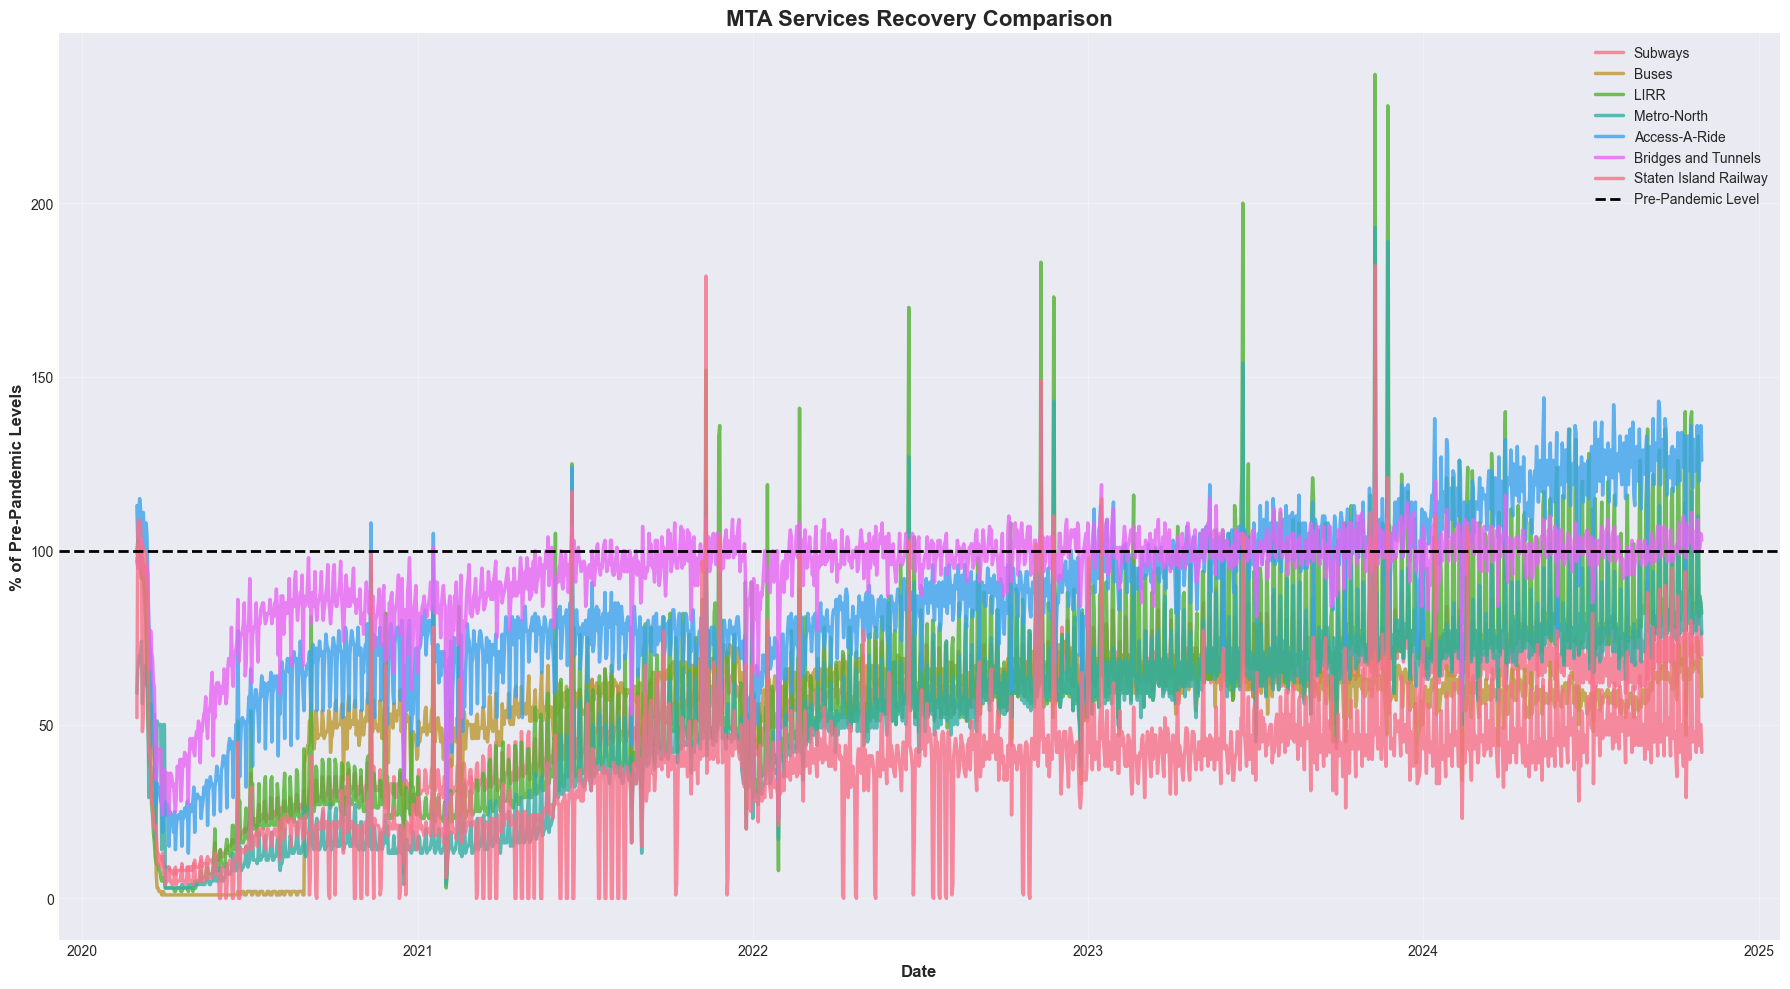

In [15]:
# Visualization: All services recovery comparison
plt.figure(figsize=(18, 10))

for service in services:
    pct_col = f'{service}_Pct'
    if pct_col in df.columns:
        plt.plot(df['Date'], df[pct_col], linewidth=2.5, label=service, alpha=0.8)

plt.axhline(y=100, color='black', linestyle='--', label='Pre-Pandemic Level', linewidth=2)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('% of Pre-Pandemic Levels', fontsize=12, fontweight='bold')
plt.title('MTA Services Recovery Comparison', fontsize=16, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Projected Full Recovery

In [16]:
# Polynomial regression projections
projections = {}

for service in services:
    pct_col = f'{service}_Pct'
    if pct_col not in df.columns:
        continue
    
    current_pct = df[pct_col].iloc[-1]
    
    if current_pct >= 100:
        # Already recovered
        projections[service] = {
            'status': 'RECOVERED',
            'current_pct': current_pct
        }
        recovered_df = df[df[pct_col] >= 100]
        if len(recovered_df) > 0:
            projections[service]['date_recovered'] = recovered_df['Date'].iloc[0]
    else:
        # Use last 180 days for trend
        recent_data = df.tail(180).copy()
        recent_data = recent_data[recent_data[pct_col].notna()]
        
        if len(recent_data) < 30:
            continue
        
        # Polynomial regression
        X = recent_data['DaysSinceMarch2020'].values.reshape(-1, 1)
        y = recent_data[pct_col].values
        
        poly = PolynomialFeatures(degree=2)
        X_poly = poly.fit_transform(X)
        model = LinearRegression()
        model.fit(X_poly, y)
        
        # Calculate trend slope
        recent_slope = np.polyfit(X.flatten(), y, 1)[0]
        
        if recent_slope <= 0:
            projections[service] = {
                'status': 'DECLINING',
                'current_pct': current_pct,
                'trend': recent_slope
            }
        else:
            # Project to 100%
            last_day = X[-1][0]
            
            for future_day in range(int(last_day), int(last_day) + 2000):
                future_X = poly.transform([[future_day]])
                predicted_pct = model.predict(future_X)[0]
                
                if predicted_pct >= 100:
                    projected_date = pd.to_datetime('2020-03-01') + timedelta(days=int(future_day))
                    projections[service] = {
                        'status': 'RECOVERING',
                        'current_pct': current_pct,
                        'projection_date': projected_date,
                        'days_until_recovery': int(future_day - last_day),
                        'trend': recent_slope
                    }
                    break

# Display projections
print("📊 RECOVERY STATUS AND PROJECTIONS:")
print("=" * 70)

recovered = [(s, p) for s, p in projections.items() if p['status'] == 'RECOVERED']
recovering = [(s, p) for s, p in projections.items() if p['status'] == 'RECOVERING']

if recovered:
    print("\n[RECOVERED] FULLY RECOVERED:")
    for service, proj in recovered:
        if 'date_recovered' in proj:
            print(f"   • {service:25s}: Recovered on {proj['date_recovered'].strftime('%Y-%m-%d')}")
        else:
            print(f"   • {service:25s}: Currently at {proj['current_pct']:.1f}%")

if recovering:
    print("\n[RECOVERING] PROJECTED TO RECOVER:")
    recovering.sort(key=lambda x: x[1]['projection_date'])
    for service, proj in recovering:
        print(f"   • {service:25s}: {proj['projection_date'].strftime('%Y-%m-%d')} "
              f"({proj['days_until_recovery']:,} days) - Currently {proj['current_pct']:.1f}%")

📊 RECOVERY STATUS AND PROJECTIONS:

[RECOVERED] FULLY RECOVERED:
   • Access-A-Ride            : Recovered on 2020-03-01
   • Bridges and Tunnels      : Recovered on 2020-03-05

[RECOVERING] PROJECTED TO RECOVER:
   • LIRR                     : 2024-11-03 (3 days) - Currently 82.0%
   • Metro-North              : 2024-12-16 (46 days) - Currently 76.0%
   • Subways                  : 2025-02-05 (97 days) - Currently 70.0%
   • Buses                    : 2025-02-13 (105 days) - Currently 58.0%


In [17]:
# Correlation analysis
pct_cols = [f'{s}_Pct' for s in services if f'{s}_Pct' in df.columns]
corr_matrix = df[pct_cols].corr()

# Display strongest correlations
correlations = []
for i in range(len(pct_cols)):
    for j in range(i+1, len(pct_cols)):
        corr_val = corr_matrix.iloc[i, j]
        correlations.append((
            pct_cols[i].replace('_Pct', ''),
            pct_cols[j].replace('_Pct', ''),
            corr_val
        ))

correlations.sort(key=lambda x: abs(x[2]), reverse=True)

print("🔗 INTER-SERVICE CORRELATIONS (Top 5):")
print("=" * 70)
for i, (s1, s2, corr) in enumerate(correlations[:5], 1):
    print(f"{i}. {s1} ↔ {s2}: {corr:.3f}")

🔗 INTER-SERVICE CORRELATIONS (Top 5):
1. Subways ↔ Metro-North: 0.928
2. LIRR ↔ Metro-North: 0.926
3. Subways ↔ LIRR: 0.915
4. Subways ↔ Access-A-Ride: 0.825
5. Subways ↔ Buses: 0.815


In [18]:
# Day of week patterns
dow_analysis = df.groupby('DayOfWeek').agg({
    'Subways_Pct': 'mean',
    'LIRR_Pct': 'mean',
    'Metro-North_Pct': 'mean'
})

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("\n📅 AVERAGE RECOVERY BY DAY OF WEEK:")
print("=" * 70)
for idx, day in enumerate(days):
    if idx in dow_analysis.index:
        print(f"{day:10s}: Subway={dow_analysis.loc[idx, 'Subways_Pct']:.1f}%, "
              f"LIRR={dow_analysis.loc[idx, 'LIRR_Pct']:.1f}%, "
              f"Metro-North={dow_analysis.loc[idx, 'Metro-North_Pct']:.1f}%")


📅 AVERAGE RECOVERY BY DAY OF WEEK:
Monday    : Subway=51.6%, LIRR=54.8%, Metro-North=48.2%
Tuesday   : Subway=53.2%, LIRR=52.4%, Metro-North=50.0%
Wednesday : Subway=54.4%, LIRR=52.3%, Metro-North=49.4%
Thursday  : Subway=54.2%, LIRR=52.8%, Metro-North=48.7%
Friday    : Subway=52.5%, LIRR=53.5%, Metro-North=48.3%
Saturday  : Subway=60.6%, LIRR=72.7%, Metro-North=51.8%
Sunday    : Subway=61.7%, LIRR=75.4%, Metro-North=61.3%


In [19]:
# Save cleaned dataset for SQL/Excel/Tableau
df.to_csv('cleaned_data.csv', index=False)
print("[OK] Cleaned data exported to 'cleaned_data.csv'")
print("  Ready for import into SQL databases, Excel, and Tableau")

[OK] Cleaned data exported to 'cleaned_data.csv'
  Ready for import into SQL databases, Excel, and Tableau


## Summary & Key Findings

In [20]:
print("="*70)
print("MTA RIDERSHIP ANALYSIS - EXECUTIVE SUMMARY")
print("="*70)
print(f"\nAnalysis Period: {df['Date'].min().strftime('%B %d, %Y')} to {df['Date'].max().strftime('%B %d, %Y')}")
print(f"Total Days Analyzed: {len(df):,}")
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

print("\n1. TRAFFIC SHARE CHANGES:")
print("   • Bridges & Tunnels: +3.65pp (shift to private vehicles)")
print("   • Buses: -3.91pp (biggest loss)")

print("\n2. BIGGEST DROP-OFFS:")
print("   • Worst: Staten Island Railway (100% drop)")
print("   • Second: Buses (99% drop)")
print("   • Fully Recovered: Access-A-Ride, Bridges & Tunnels")

print("\n3. FASTEST RECOVERY:")
print("   • Quickest to 100%: Bridges & Tunnels (97 days)")
print("   • Highest Velocity: Access-A-Ride (0.069 pp/day)")

print("\n4. RECOVERY TIMELINE:")
print("   • All major services projected to recover by February 2025")
print("   • Permanent structural changes in commute patterns likely")

print("\n" + "="*70)
print("[RECOVERED] ANALYSIS COMPLETE")
print("="*70)

MTA RIDERSHIP ANALYSIS - EXECUTIVE SUMMARY

Analysis Period: March 01, 2020 to October 31, 2024
Total Days Analyzed: 1,706

KEY FINDINGS

1. TRAFFIC SHARE CHANGES:
   • Bridges & Tunnels: +3.65pp (shift to private vehicles)
   • Buses: -3.91pp (biggest loss)

2. BIGGEST DROP-OFFS:
   • Worst: Staten Island Railway (100% drop)
   • Second: Buses (99% drop)
   • Fully Recovered: Access-A-Ride, Bridges & Tunnels

3. FASTEST RECOVERY:
   • Quickest to 100%: Bridges & Tunnels (97 days)
   • Highest Velocity: Access-A-Ride (0.069 pp/day)

4. RECOVERY TIMELINE:
   • All major services projected to recover by February 2025
   • Permanent structural changes in commute patterns likely

[RECOVERED] ANALYSIS COMPLETE
